In [1]:
from google.colab import files

uploaded = files.upload()

Saving Food_Waste_Prediction_Dataset (1).xlsx to Food_Waste_Prediction_Dataset (1).xlsx


In [2]:
import pandas as pd

df = pd.read_excel("/content/Food_Waste_Prediction_Dataset (1).xlsx")

print(df.head())

  Restaurant_ID Restaurant_Name        City       Cuisine Food_Item  \
0          R001    Spice Garden     Chennai  South Indian    Pongal   
1          R005      Green Bowl      Mumbai  South Indian      Dosa   
2          R002     Urban Bites   Bengaluru       Italian     Pasta   
3          R004        Food Hub  Coimbatore  South Indian     Meals   
4          R003     Ocean Treat   Hyderabad  South Indian      Dosa   

         Date  Prepared_Quantity  Sold_Quantity  Remaining_Quantity  \
0  2025-05-06                107            102                   5   
1  2025-11-29                229            198                  31   
2  2025-05-23                 89             89                   0   
3  2025-02-10                191            175                  16   
4  2025-02-21                147            113                  34   

   Temperature_C Weather Weekend Holiday  Discount_Percent  Customers  \
0             25  Cloudy      No      No                20        121   


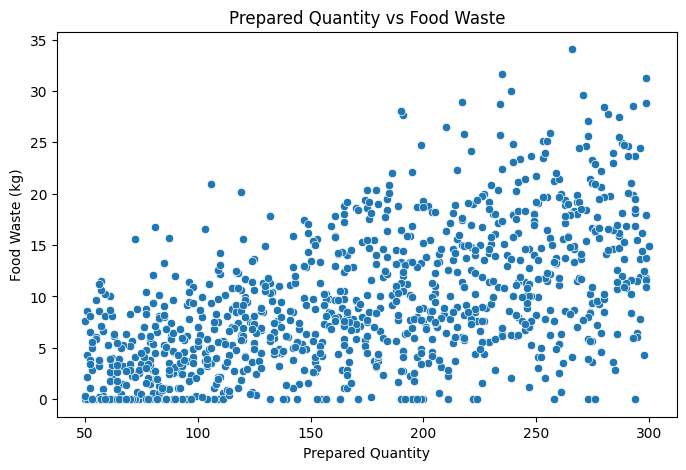

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Prepared_Quantity",
    y="Waste_Amount_kg"
)

plt.title("Prepared Quantity vs Food Waste")
plt.xlabel("Prepared Quantity")
plt.ylabel("Food Waste (kg)")

plt.show()

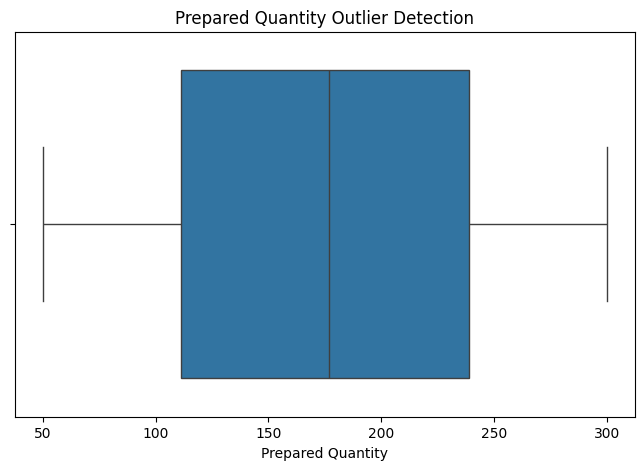

In [4]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Prepared_Quantity"]
)

plt.title("Prepared Quantity Outlier Detection")
plt.xlabel("Prepared Quantity")

plt.show()

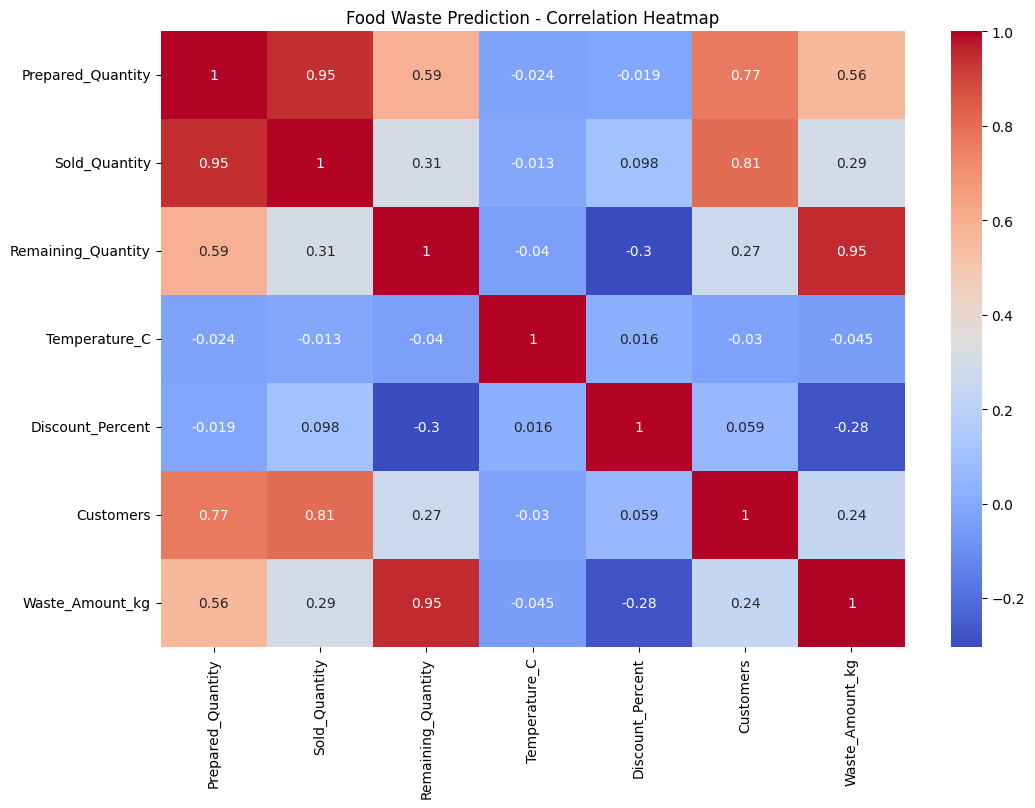

In [5]:
plt.figure(figsize=(12, 8))

corr = df[
    [
        "Prepared_Quantity",
        "Sold_Quantity",
        "Remaining_Quantity",
        "Temperature_C",
        "Discount_Percent",
        "Customers",
        "Waste_Amount_kg"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Food Waste Prediction - Correlation Heatmap")
plt.show()

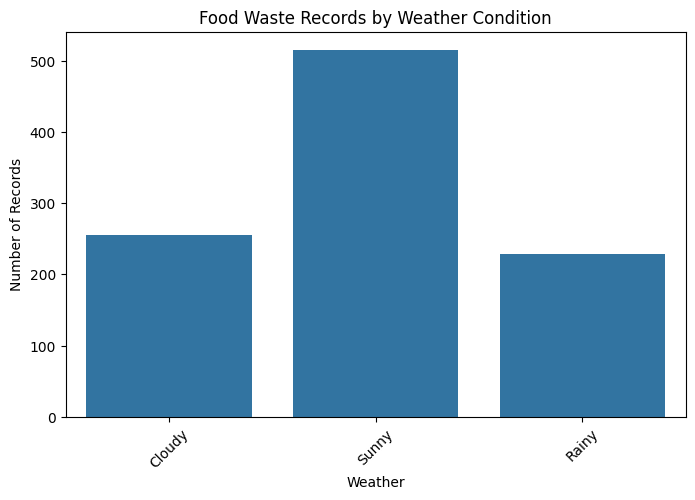

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Weather"
)

plt.xticks(rotation=45)

plt.title("Food Waste Records by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Records")

plt.show()

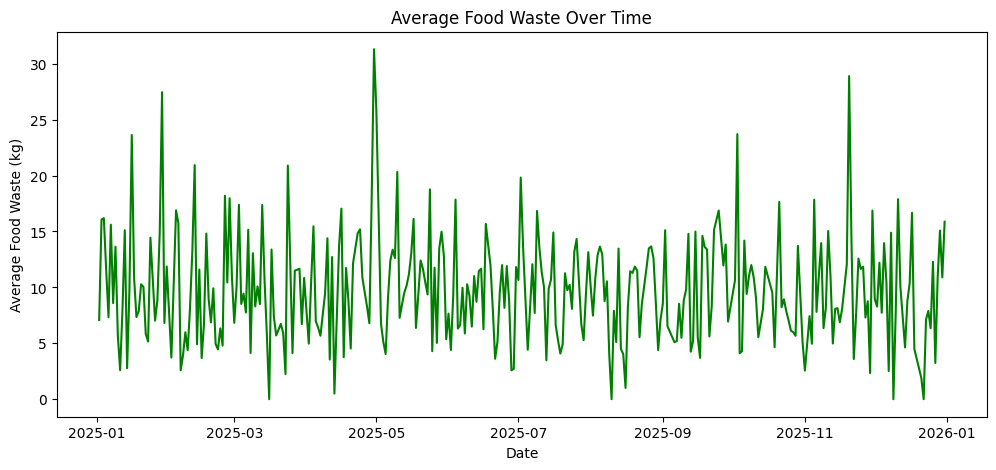

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

daily = df.groupby("Date")["Waste_Amount_kg"].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    daily,
    color="green"
)

plt.title("Average Food Waste Over Time")
plt.xlabel("Date")
plt.ylabel("Average Food Waste (kg)")

plt.show()

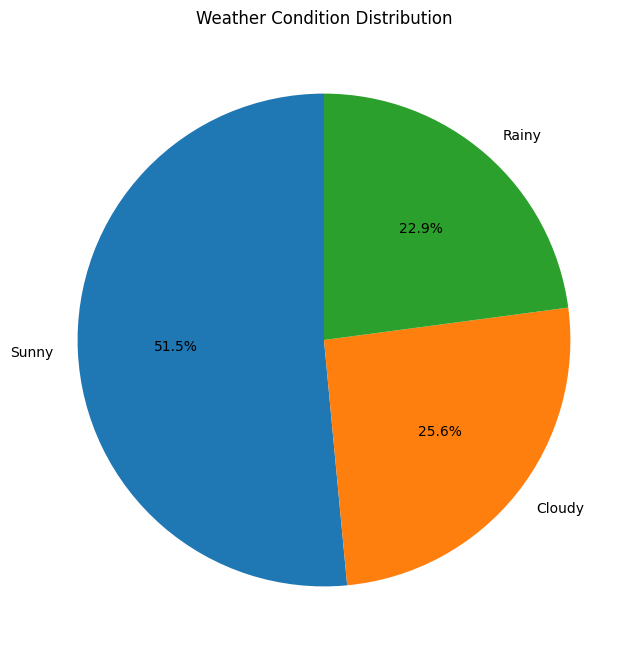

In [8]:
weather = df["Weather"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    weather,
    labels=weather.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Weather Condition Distribution")

plt.show()

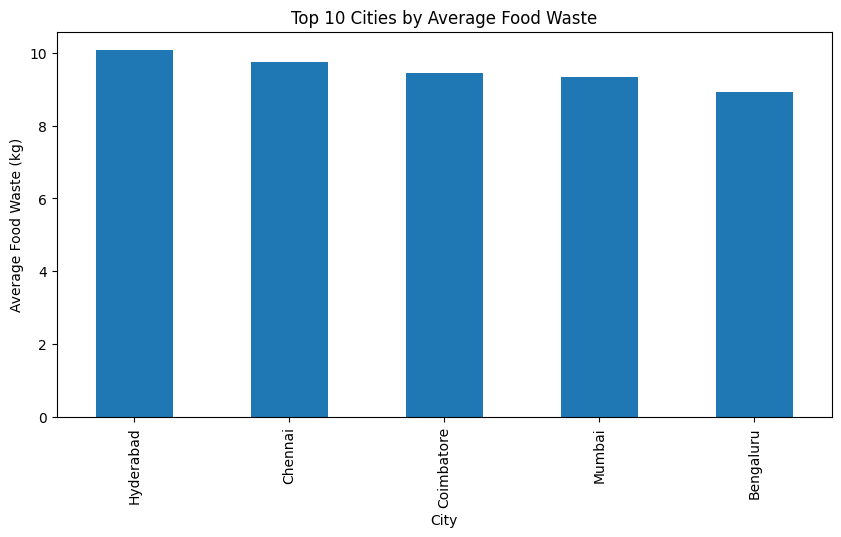

In [9]:
city = df.groupby("City")["Waste_Amount_kg"].mean()

city = city.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))

city.plot(kind="bar")

plt.title("Top 10 Cities by Average Food Waste")
plt.xlabel("City")
plt.ylabel("Average Food Waste (kg)")

plt.show()

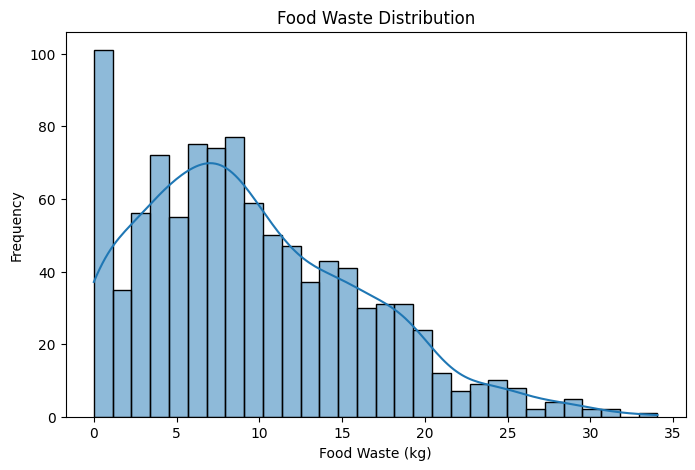

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Waste_Amount_kg"],
    bins=30,
    kde=True
)

plt.title("Food Waste Distribution")
plt.xlabel("Food Waste (kg)")
plt.ylabel("Frequency")

plt.show()

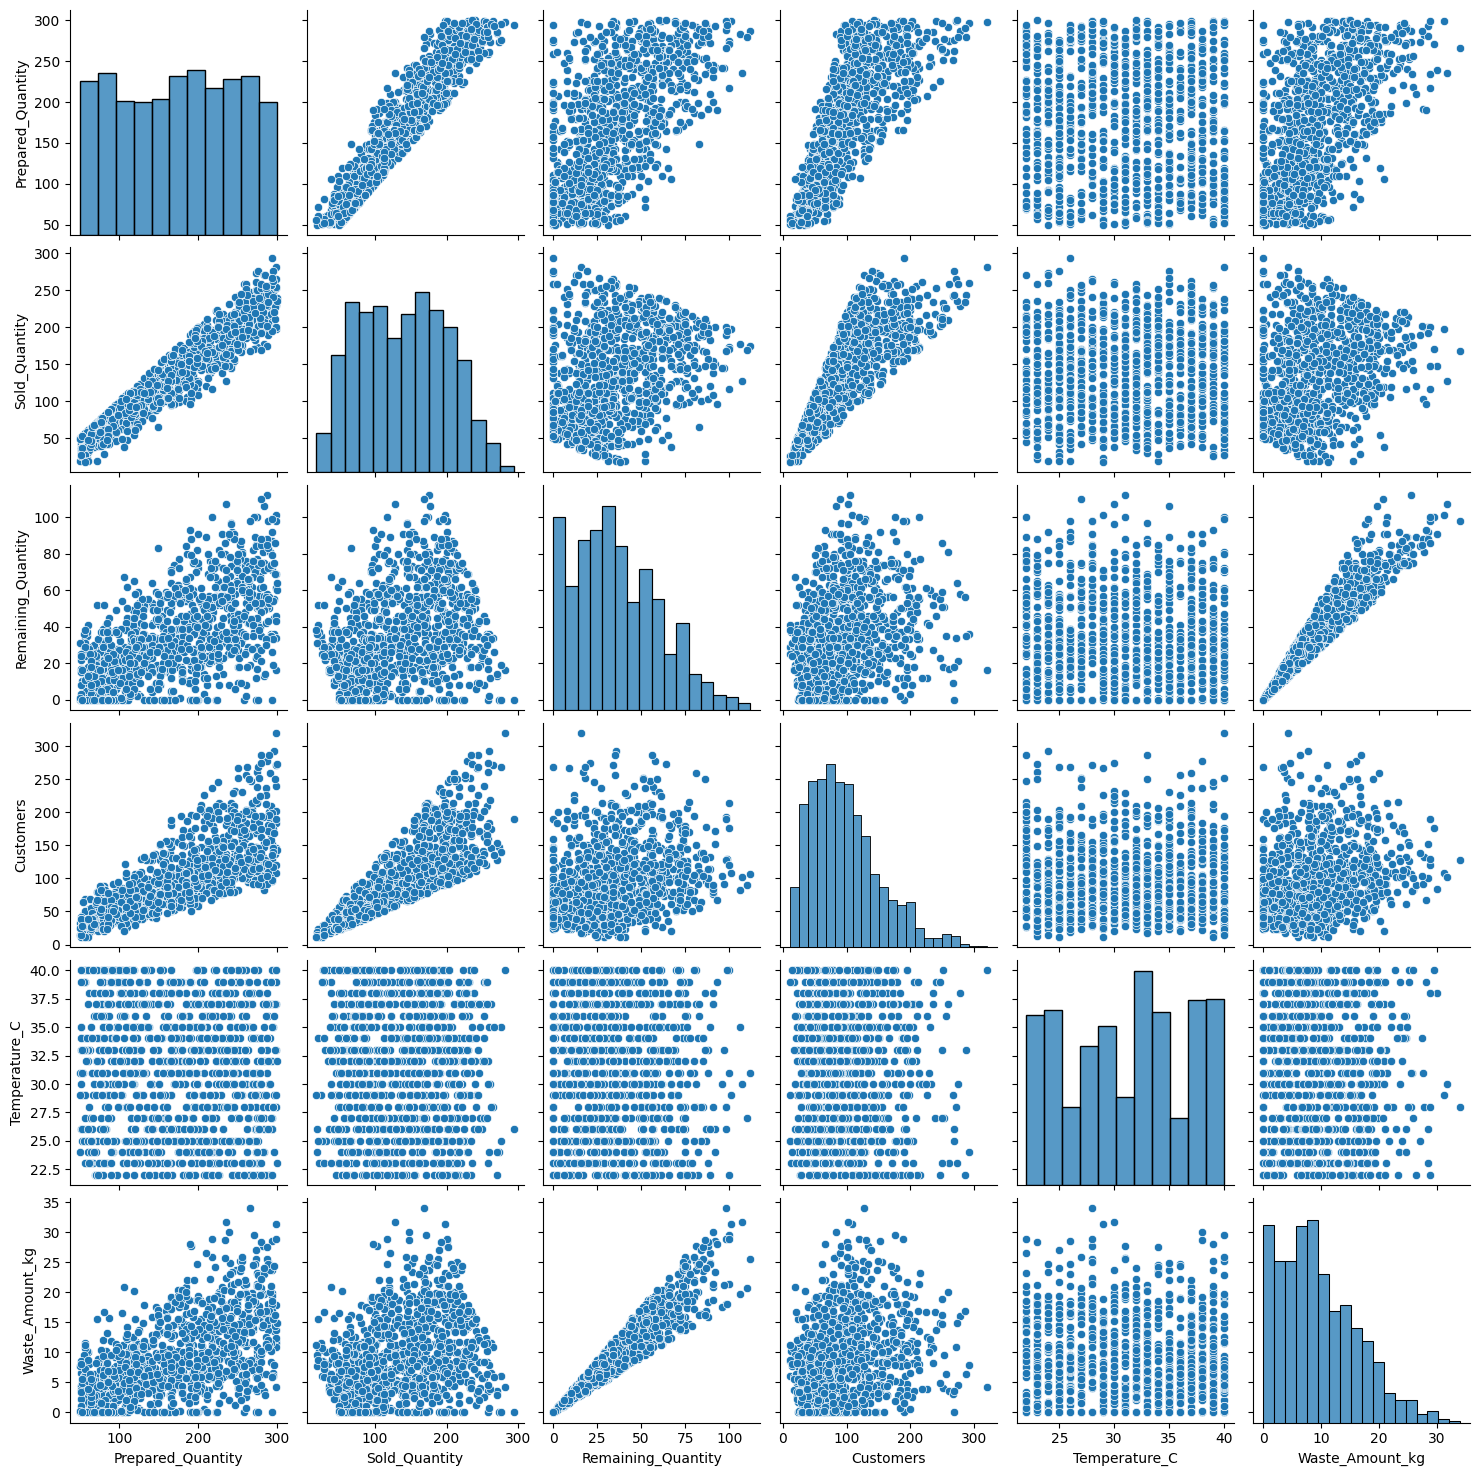

In [11]:
sns.pairplot(
    df[
        [
            "Prepared_Quantity",
            "Sold_Quantity",
            "Remaining_Quantity",
            "Customers",
            "Temperature_C",
            "Waste_Amount_kg"
        ]
    ]
)

plt.show()

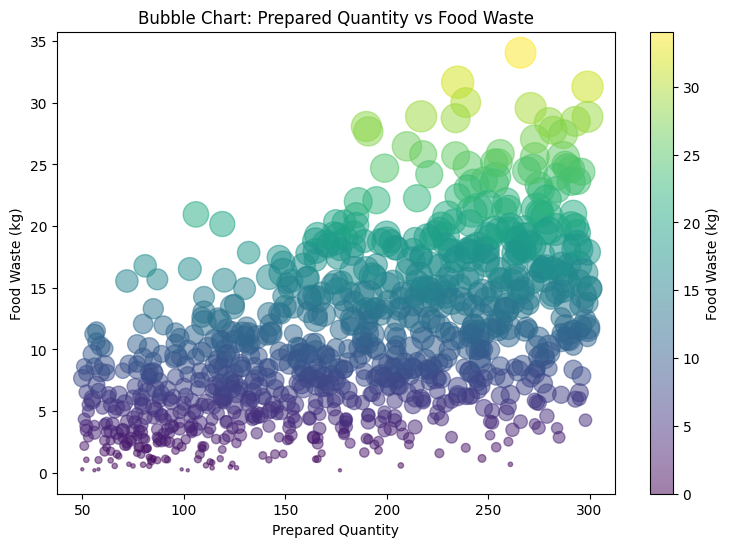

In [12]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Prepared_Quantity"],
    df["Waste_Amount_kg"],
    s=df["Remaining_Quantity"] * 5,
    alpha=0.5,
    c=df["Waste_Amount_kg"],
    cmap="viridis"
)

plt.colorbar(label="Food Waste (kg)")

plt.xlabel("Prepared Quantity")
plt.ylabel("Food Waste (kg)")

plt.title("Bubble Chart: Prepared Quantity vs Food Waste")

plt.show()

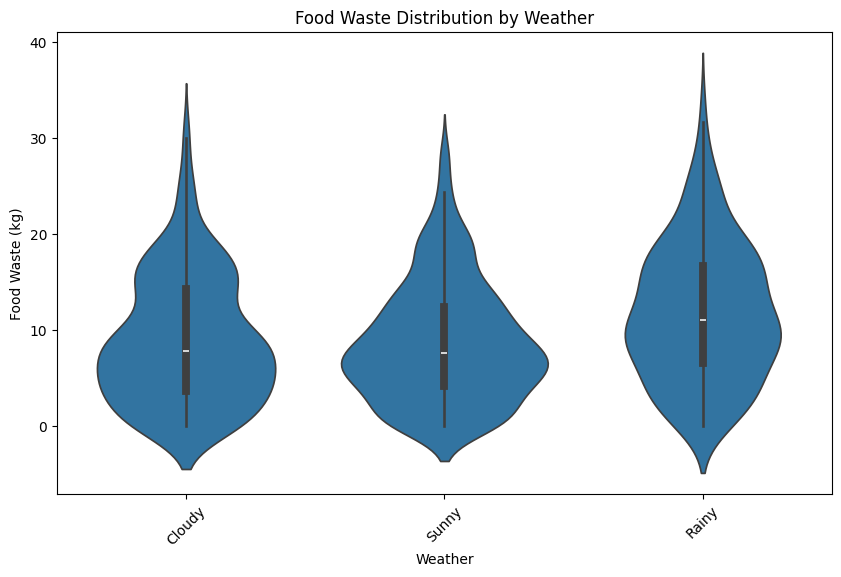

In [13]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Weather",
    y="Waste_Amount_kg"
)

plt.xticks(rotation=45)

plt.title("Food Waste Distribution by Weather")
plt.xlabel("Weather")
plt.ylabel("Food Waste (kg)")

plt.show()

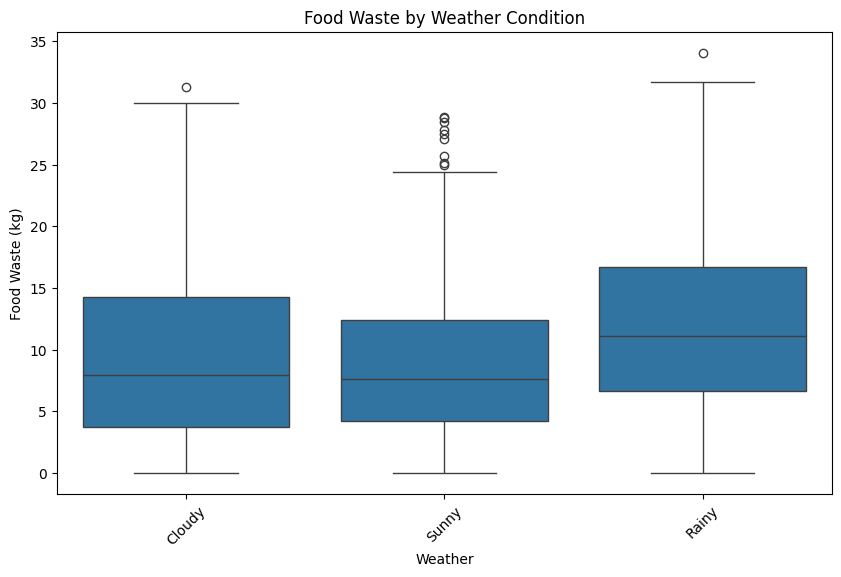

In [14]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Weather",
    y="Waste_Amount_kg"
)

plt.xticks(rotation=45)

plt.title("Food Waste by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Food Waste (kg)")

plt.show()